# Assignment 7
## Topic: Logistic Regression

### Question 1
Load the UCI Heart Disease dataset and identify the target variable.

Dataset Link: [archive.ics.uci.edu](https://archive.ics.uci.edu/dataset/45/heart+disease)

In [1]:
import pandas as pd
# Load dataset
df = pd.read_csv("Assignment_7.csv")
# Display first rows
print(df.head())
# Identify target variable
print("Target variable:", "target")

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   3       145   233    1        0      150      0      2.3      0   
1   37    1   2       130   250    0        1      187      0      3.5      0   
2   41    0   1       130   204    0        0      172      0      1.4      2   
3   56    1   1       120   236    0        1      178      0      0.8      2   
4   57    0   0       120   354    0        1      163      1      0.6      2   

   ca  thal  target  
0   0     1       1  
1   0     2       1  
2   0     2       1  
3   0     2       1  
4   0     2       1  
Target variable: target


### Question 2
List the independent features used to predict the presence of heart disease and state the type of each feature (numerical or categorical).

In [2]:
# List independent features
features = df.columns.drop("target")
print("Independent Features:")
print(features)

Independent Features:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal'],
      dtype='str')


### Question 3
Do the preprocessing steps required before applying Logistic Regression on the UCI Heart Disease dataset. including handling of missing values, encoding of categorical variables, and feature scaling.

In [3]:
print("----- Preprocessing Steps -----")

# Check missing values
print("\nChecking Missing Values:")
print(df.isnull().sum())

# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print("\nFeatures and target separated.")
from sklearn.preprocessing import StandardScaler
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nFeature Scaling completed using StandardScaler.")

----- Preprocessing Steps -----

Checking Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Features and target separated.

Feature Scaling completed using StandardScaler.


### Question 4
Using Python, build a Logistic Regression model to predict whether a patient has heart disease.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

print("----- Building Logistic Regression Model -----")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Data split into Training and Testing sets.")

# Model
model = LogisticRegression()

# Train model
model.fit(X_train, y_train)

print("Logistic Regression Model Trained Successfully.")

# Predictions
y_pred = model.predict(X_test)

----- Building Logistic Regression Model -----
Data split into Training and Testing sets.
Logistic Regression Model Trained Successfully.


### Question 5
Evaluate the trained Logistic Regression model using accuracy, confusion matrix, precision, recall, and F1-score.

----- Model Evaluation -----
Accuracy: 0.8524590163934426

Confusion Matrix:
[[25  4]
 [ 5 27]]


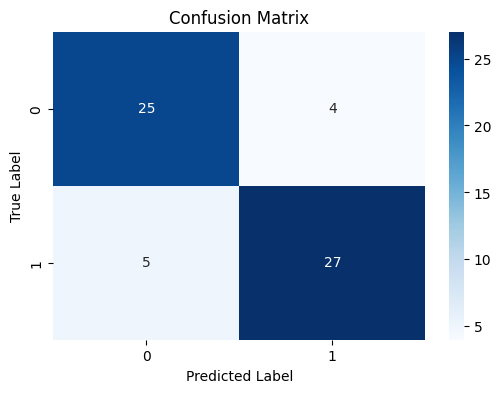


Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.86      0.85        29
           1       0.87      0.84      0.86        32

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [5]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
print("----- Model Evaluation -----")

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()
# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

### Question 5
Plot ROC Curve

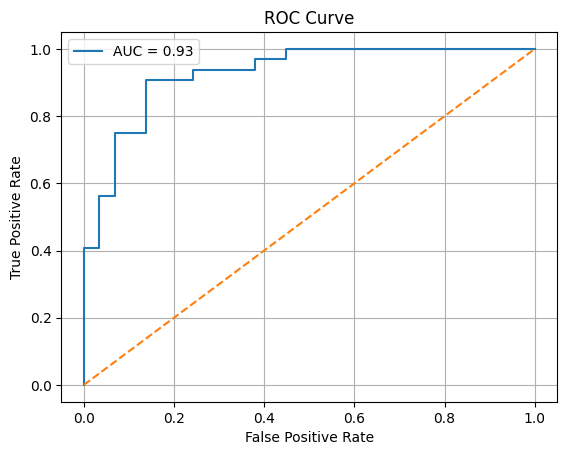

In [6]:
from sklearn.metrics import roc_curve, roc_auc_score\

# Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# AUC score
auc = roc_auc_score(y_test, y_prob)

# Plot ROC
plt.plot(fpr, tpr, label="AUC = %.2f" % auc)
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.show()